<a href="https://colab.research.google.com/github/urashlei/mliot-pyml-2026-hw/blob/main/week01/buoi02_nguyenbaotien.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phần 1 — Thống kê mô tả & đặc trưng

1. Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng
cột.

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

# tải dữ liệu
df=sns.load_dataset('iris')
# hiển thị 5 dòng đầu
print('5 dòng đầu của dữ liệu:')
print(df.head())
#hiển thị số dòng, số cột
print(f'\nSố dòng: {df.shape[0]}, Số cột: {df.shape[1]}')
# kiểu dữ liệu của từng cột
print('\nKiểu dữ liệu từng cột:')
print(df.dtypes)

5 dòng đầu của dữ liệu:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Số dòng: 150, Số cột: 5

Kiểu dữ liệu từng cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


2. Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và
IQR.


In [2]:
# chọn cột số
numeric_df=df.select_dtypes(include=[np.number])

stats_df = pd.DataFrame({
    'mean': numeric_df.mean(),
    'median': numeric_df.median(),
    'mode': numeric_df.mode().iloc[0],
    'var': numeric_df.var(),
    'std': numeric_df.std(),
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'Q1': numeric_df.quantile(0.25),
    'Q3': numeric_df.quantile(0.75)
})

stats_df['IQR'] = stats_df['Q3'] - stats_df['Q1']

print('Bảng thống kê:')
print(stats_df.T)

Bảng thống kê:
        sepal_length  sepal_width  petal_length  petal_width
mean        5.843333     3.057333      3.758000     1.199333
median      5.800000     3.000000      4.350000     1.300000
mode        5.000000     3.000000      1.400000     0.200000
var         0.685694     0.189979      3.116278     0.581006
std         0.828066     0.435866      1.765298     0.762238
min         4.300000     2.000000      1.000000     0.100000
max         7.900000     4.400000      6.900000     2.500000
Q1          5.100000     2.800000      1.600000     0.300000
Q3          6.400000     3.300000      5.100000     1.800000
IQR         1.300000     0.500000      3.500000     1.500000


Các chỉ số trung bình và trung vị của mỗi biến khá gần nhau, chứng tỏ dữ liệu không bị lệch quá nhiều. Biến petal_length và petal_width có độ lệch chuẩn lớn hơn, IQR cũng rộng hơn so với hai biến đài hoa, cho thấy các giá trị cánh hoa phân tán rõ rệt hơn, có thể do sự khác biệt giữa các loài.

3. Theo từng nhóm (loài species): dùng groupby tính mean và std của từng biến. Nhận xét nhóm nào khác biệt rõ nhất.

In [3]:
# groupby theo loài và tính mean, std
group_stats=df.groupby('species').agg(['mean', 'std'])

print('Thống kê mean và std theo từng loài:')
print(group_stats)

Thống kê mean và std theo từng loài:
           sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650  


Dựa trên bảng mean của từng biến theo loài, ta thấy:
- Loài setosa có kích thước các bộ phận nhỏ nhất trong ba loài.
- Loài virginica có kích thước lớn nhất, đặc biệt là chiều dài và rộng cánh hoa.
- Loài versicolor nằm ở khoảng giữa.
Sự khác biệt rõ rệt nhất thể hiện ở hai biến:
- Chiều dài cánh hoa: trung bình của setosa ≈ 1.462, versicolor ≈ 4.26, virginica ≈ 5.552.
- Chiều rộng cánh hoa: trung bình setosa ≈ 0.246, versicolor ≈ 1.326, virginica ≈ 2.026.
Các biến về đài hoa (sepal_length, sepal_width) cũng có sự khác biệt nhưng không tách bạch bằng.
Nhóm setosa khác biệt hoàn toàn so với hai nhóm còn lại ở cả bốn biến; giữa versicolor và virginica cũng có sự phân tách rõ ở các biến cánh hoa.

Phần 2 — Phân phối xác suất

1. Vẽ histogram + KDE cho từng biến số. Nhận xét hình dạng phân phối: lệch trái/phải, gần phân phối chuẩn, hay nhiều đỉnh?

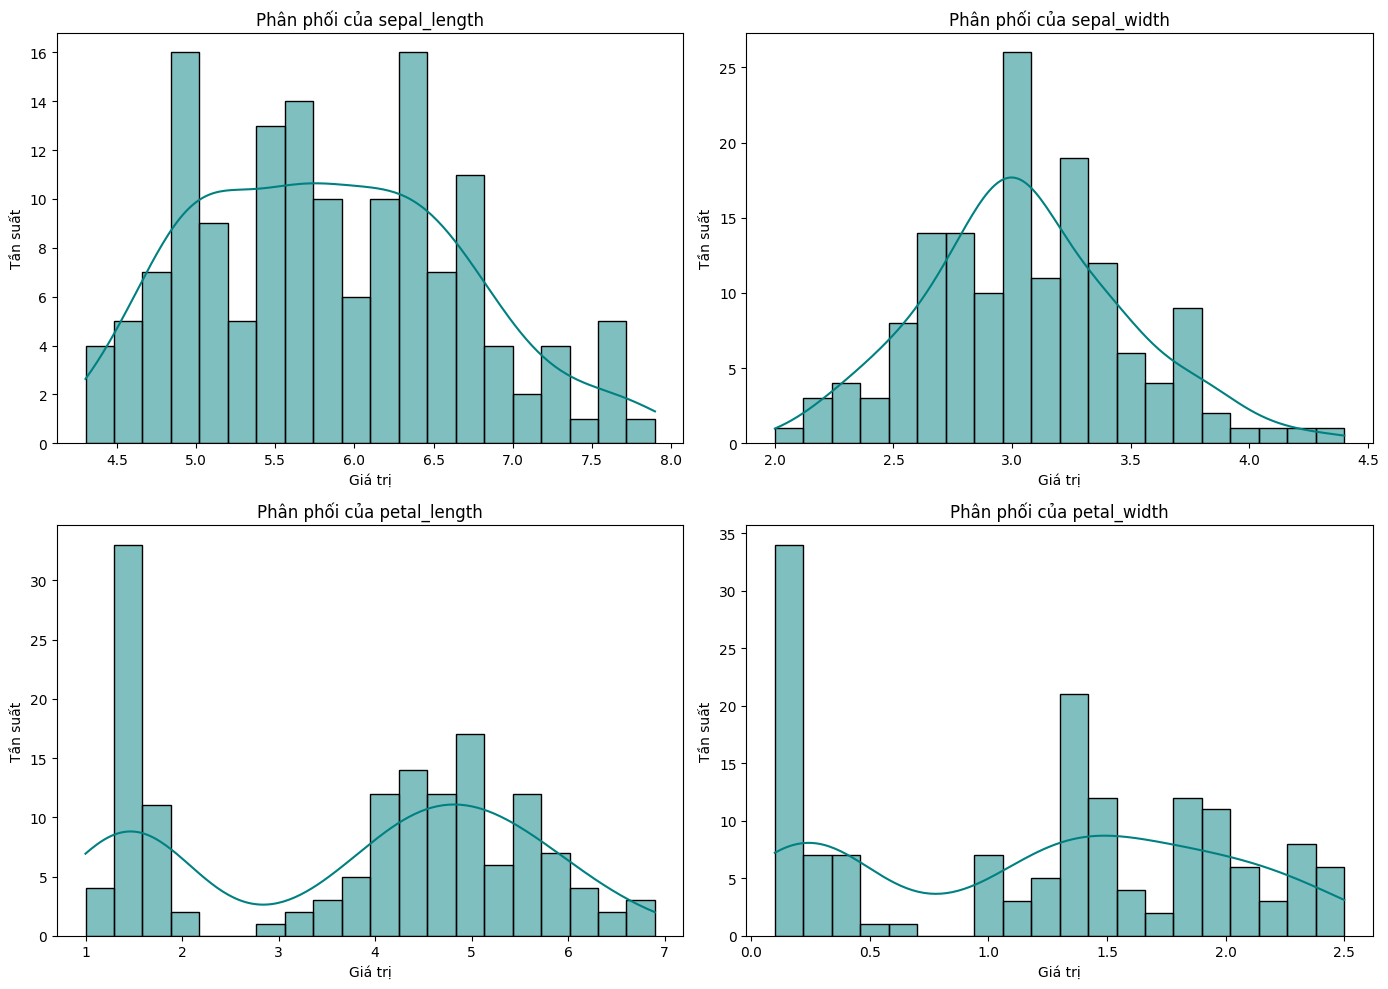

In [4]:
import matplotlib.pyplot as plt

cols=numeric_df.columns
# tạo khung cho 4 biến số
fig, axes=plt.subplots(2, 2, figsize=(14, 10))
axes=axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=20)
    axes[i].set_title(f'Phân phối của {col}')
    axes[i].set_xlabel('Giá trị')
    axes[i].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

1. sepal_length
Biểu đồ đối xứng khá cân đối hai bên, trông gần giống phân phối chuẩn. Có thể hơi lệch phải một chút nhưng cx ko đáng kể.
2. sepal_width
Cũng gần đối xứng nhưng nhìn chung cx khá giống phân phối chuẩn.
==> Giá trị Mean và Median của hai biến này thường xấp xỉ nhau, cho thấy dữ liệu tập trung mạnh quanh giá trị trung bình và ít bị ảnh hưởng bởi các giá trị ngoại lai (outliers)

3. petal_length
Phân phối này không có dạng chuẩn. Nó thể hiện rõ 2 đỉnh (có thể thấy gần 3 đỉnh nhỏ), vì dữ liệu bao gồm 3 loài hoa khác nhau với kích thước cánh hoa khác biệt hoàn toàn. Đây là phân phối đa đỉnh.
4. petal_width
Tương tự như petal_length, biểu đồ có 2 đỉnh rõ rệt, không hề giống với phân phối chuẩn, phản ánh sự khác biệt lớn giữa các loài, đặc biệt là loài setosa có cánh hoa rất nhỏ.
==> Phân phối của cánh hoa không đối xứng, cho thấy sự không đồng nhất giữa các nhóm đối tượng trong tập dữ liệu.

2. Vẽ boxplot từng biến theo nhóm (species) để so sánh phân phối giữa các loài.

/tmp/ipykernel_59545/2574751281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_59545/2574751281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_59545/2574751281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_59545/2574751281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

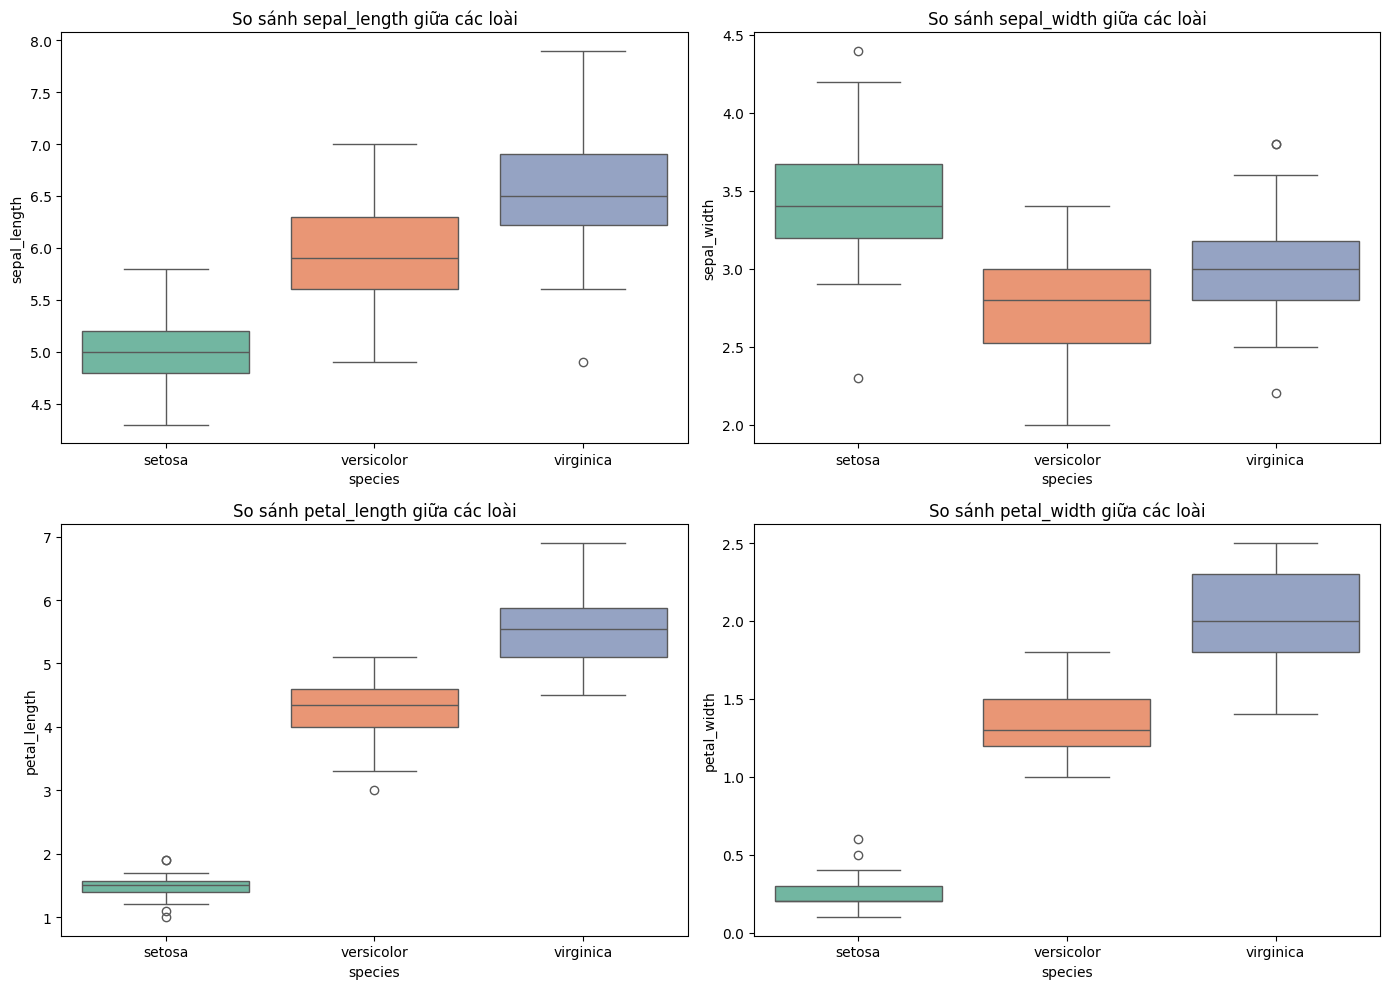

In [5]:
fig, axes=plt.subplots(2, 2, figsize=(14, 10))
axes=axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, x='species', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'So sánh {col} giữa các loài')

plt.tight_layout()
plt.show()

- Loài Setosa khác biệt hoàn toàn: cánh hoa nhỏ nhất nhưng đài hoa lại rộng nhất, dễ dàng tách khỏi hai loài còn lại ở cả 4 biến.
- Hai biến cánh hoa (petal_length, petal_width) giúp phân biệt cả 3 loài rất rõ vì các hộp đứng tách biệt, không chồng lấn.
- Với sepal_width, Versicolor và Virginica gần như trộn lẫn hoàn toàn nên khó dùng biến này để phân loại hai loài này.
==> Cánh hoa là đặc trưng quan trọng nhất để phân biệt 3 loài, còn đài hoa chỉ giúp tách Setosa ra.

3. Mô phỏng: chọn một biến, sinh mẫu từ phân phối Normal có cùng mean và std bằng np.random.normal; vẽ chồng histogram dữ liệu thực tế với đường PDF lý thuyết. Nhận xét mức độ khớp.

Chọn biến sepal_length vì nó có dạng gần chuẩn nhất



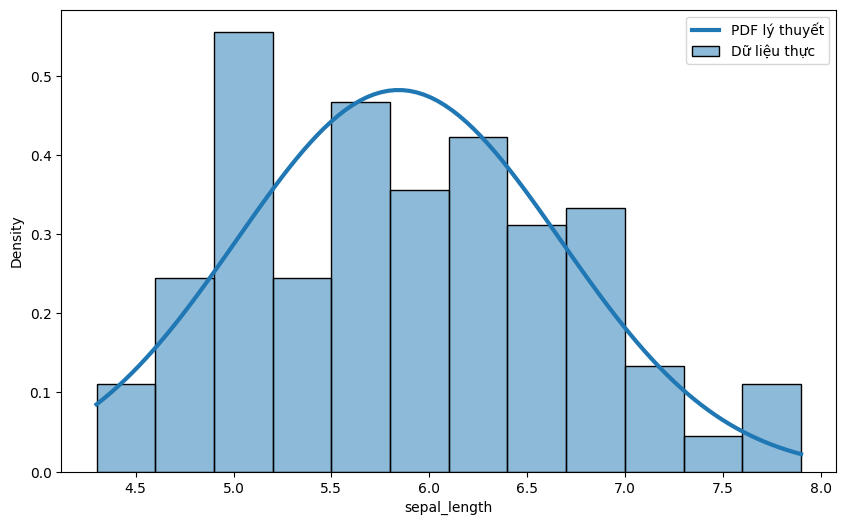

In [6]:
from scipy.stats import norm

col='sepal_length'
mean, std=df[col].mean(), df[col].std()

sample=np.random.normal(mean, std, 10000)

plt.figure(figsize=(10, 6))
# vẽ histogram
sns.histplot(df[col], stat='density', bins=12, alpha=0.5, label='Dữ liệu thực')

# vẽ đường PDF lý thuyết
x= np.linspace(df[col].min(), df[col].max(), 100)
plt.plot(x, norm.pdf(x, mean, std), lw=3, label='PDF lý thuyết')

plt.legend()
plt.show()

Đường cong lý thuyết bám khá sát các cột histogram, nhất là vùng trung tâm. Tuy nhiên, dữ liệu thực tế vẫn có những khoảng trống hoặc đỉnh hơi lệch so với lý thuyết do cỡ mẫu thực tế chỉ có 150 dòng (nhỏ so với 10000 mẫu sinh ra ngẫu nhiên). Nhìn chung thì sepal_length có thể coi là xấp xỉ chuẩn trong khuôn khổ bài tập này.

Phần 3 — Phân tích đa biến & tương quan

1. Tính ma trận hiệp phương sai (covariance) và tương quan (correlation) giữa các biến số.


In [7]:
cov_matrix=numeric_df.cov()
corr_matrix = numeric_df.corr()

print('Ma trận hiệp phương sai (Covariance):')
print(cov_matrix)
print('\nMa trận tương quan (Correlation):')
print(corr_matrix)

Ma trận hiệp phương sai (Covariance):
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

Ma trận tương quan (Correlation):
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


Cặp biến tương quan mạnh nhất là cặp Petal Length và Petal Width có hệ số tương quan cực cao ~0.96. Điều này cho thấy khi chiều dài cánh hoa tăng, chiều rộng cũng tăng theo một tỷ lệ rất ổn định (tương quan dương hoàn hảo ≈ 1)


2. Vẽ heatmap tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu đa cộng tuyến không?

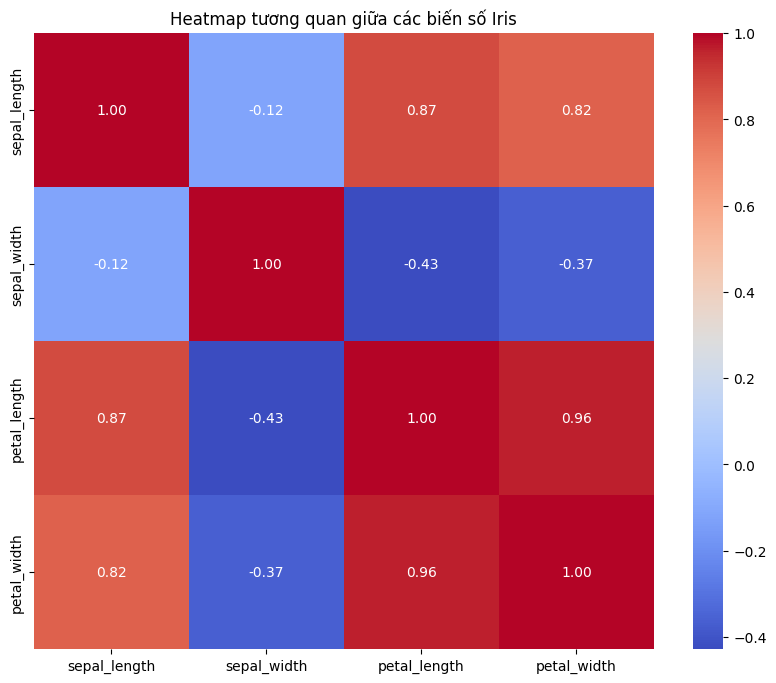

In [8]:

# vẽ heatmap tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap tương quan giữa các biến số Iris')
plt.show()

Có dấu hiệu đa cộng tuyến vì tương quan giữa petal_length và petal_width rất cao (0.96). Nếu mình đưa cả hai biến này vào cùng một mô hình hồi quy ,chúng sẽ cung cấp thông tin dư thừa, gây khó khăn cho việc ước lượng hệ số.

3. Vẽ pairplot (hoặc scatter theo cặp), tô màu theo species; nhận xét quan hệ giữa các biến.

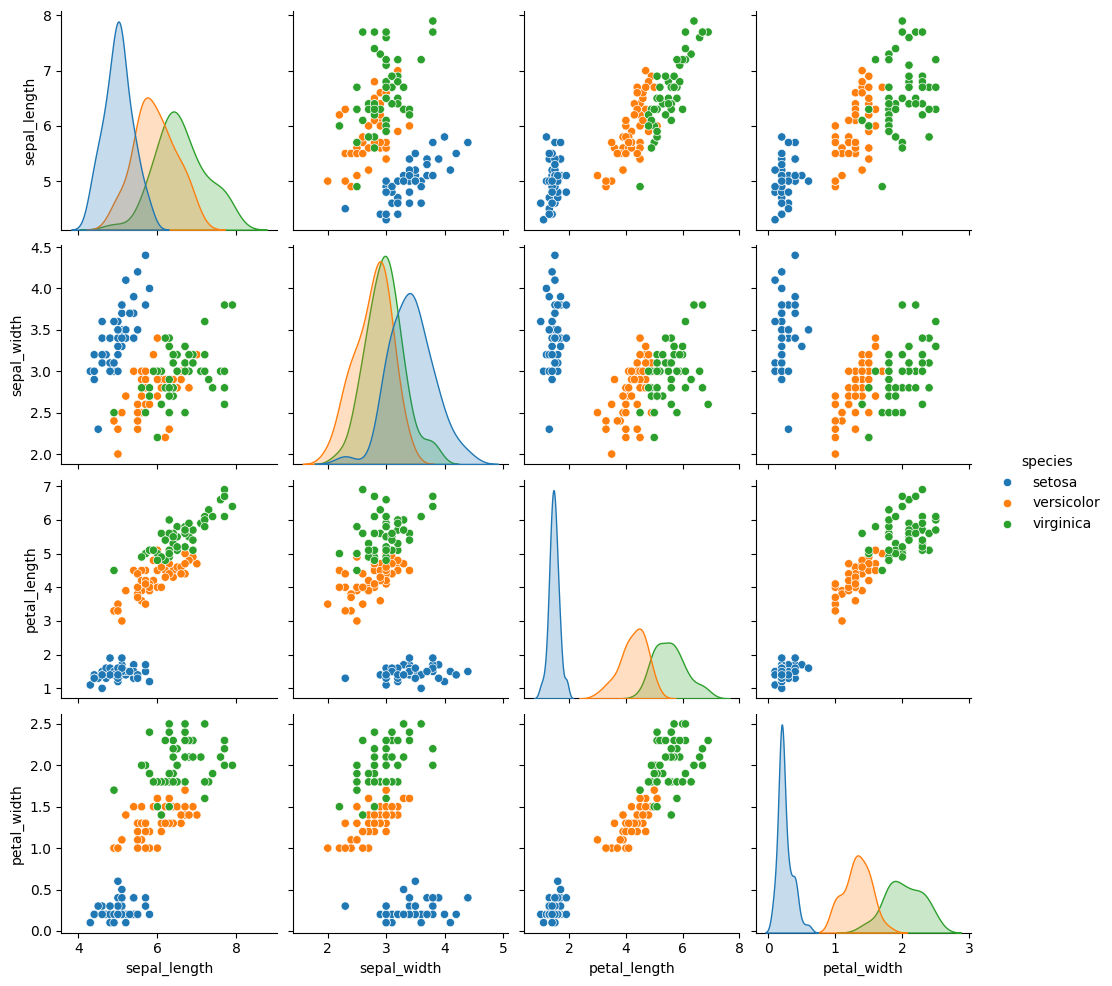

In [9]:
sns.pairplot(df, hue='species', diag_kind='kde')
plt.show()

- Loài setosa tách biệt hoàn toàn với hai loài còn lại ở tất cả các cặp biến (đặc biệt rõ ở cánh hoa), chứng tỏ Setosa có vị trí độc lập trong không gian đặc trưng.
- Versicolor và virginica có sự chồng lấn ở các biến đài hoa, cho thấy chúng chia sẻ nhiều đặc tính tương đồng về mặt sinh học.
- Các đường xu hướng đều dốc lên (tương quan dương), ngoại trừ sepal_width với các biến khác có tương quan yếu hoặc âm (như với petal_length).



Phần 4 — Xác suất & Định lý Bayes

Bài toán chẩn đoán. Một bệnh có tỉ lệ mắc trong dân số là P(B) = 0.01. Một xét
nghiệm có:
• Độ nhạy (true positive): P(+ | B) = 0.99.
• Dương tính giả (false positive): P(+ | ¬B) = 0.05.


1. Viết code tính xác suất hậu nghiệm P(B | +) bằng định lý Bayes và in kết quả.

In [10]:
P_B=0.01
P_positive_givenB=0.99
P_positive_givennotB=0.05
# tính xác suất toàn phần P(+)
P_positive=P_positive_givenB * P_B + P_positive_givennotB * (1 - P_B)
# tính xác suất hậu nghiệm P(B|+) theo định lý Bayes
P_B_given_positive = (P_positive_givenB * P_B) / P_positive

print(f'Xác suất thực sự mắc bệnh khi kết quả dương tính: {P_B_given_positive:.4f}')

Xác suất thực sự mắc bệnh khi kết quả dương tính: 0.1667


2. Khảo sát: vẽ đồ thị P(B | +) khi tỉ lệ mắc bệnh P(B) thay đổi từ 0.001 đến 0.2. Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác".

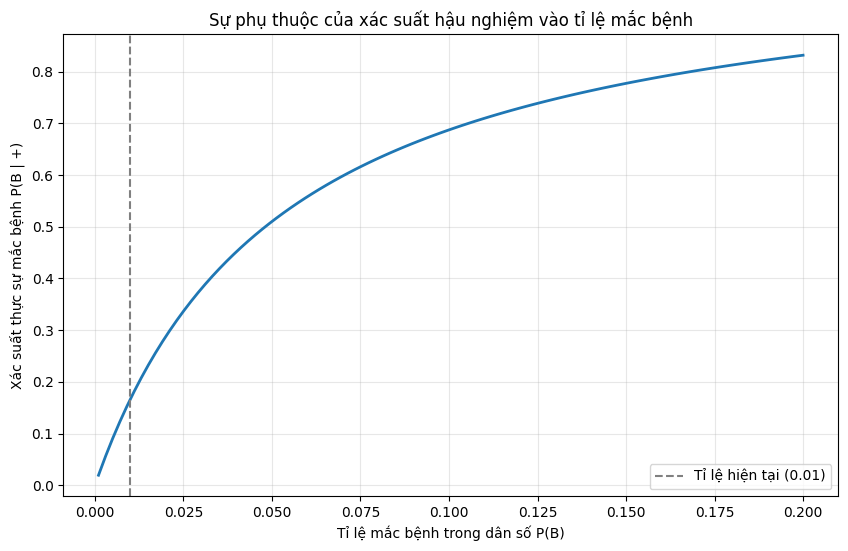

In [11]:
p_B_range = np.linspace(0.001, 0.2, 100)

# hàm tính Bayes
def posterior(p_prior):
    p_total_positive=P_positive_givenB * p_prior + P_positive_givennotB * (1 - p_prior)
    return (P_positive_givenB * p_prior) / p_total_positive

v_posterior= [posterior(p) for p in p_B_range]

plt.figure(figsize=(10, 6))
plt.plot(p_B_range, v_posterior, lw=2)
plt.axvline(0.01, color='gray', linestyle='--', label='Tỉ lệ hiện tại (0.01)')
plt.title('Sự phụ thuộc của xác suất hậu nghiệm vào tỉ lệ mắc bệnh')
plt.xlabel('Tỉ lệ mắc bệnh trong dân số P(B)')
plt.ylabel('Xác suất thực sự mắc bệnh P(B | +)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Khi bệnh hiếm (P(B) = 0.01), mặc dù xét nghiệm rất nhạy (99%), xác suất thực sự bị bệnh khi có kết quả dương tính chỉ ≈ 16.7%. Vì trong 10000 người, có 100 người bị bệnh (1%). Xét nghiệm sẽ bắt đúng 99 người trong số đó (99%). Nhưng trong 9900 người khỏe mạnh, xét nghiệm báo sai 5% tức là 495 người khỏe mạnh vẫn nhận kết quả dương tính giả. Vậy có tổng cộng 99 + 495 = 594 người nhận kết quả dương tính, nhưng chỉ có 99 người thực sự bị bệnh. Do đó, xác suất để một người có kết quả dương tính thực sự bị bệnh là 99/594 = 16.7%. Khi bệnh càng hiếm, số người khỏe mạnh bị chẩn đoán nhầm càng nhiều, lấn át số người bị bệnh thật, nên P(B|+) thấp. Khi tỉ lệ mắc tăng lên, tỉ lệ này cũng tăng.